Generated 50 train samples and 50 test samples
МНК: w = 9.8639, b = -7.5919
МНК — MSE: 147.2318, MAE: 10.3013
sklearn — MSE: 147.2318, MAE: 10.3013


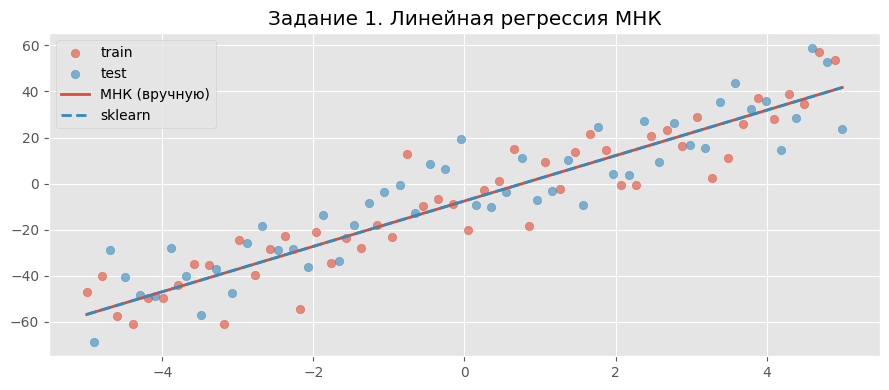

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# Задание 1

def generate_data(n_points=20):
    X = np.linspace(-5, 5, n_points)
    y = 10 * X - 7
    X_train = X[0::2].reshape(-1, 1)
    y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10
    X_test  = X[1::2].reshape(-1, 1)
    y_test  = y[1::2] + np.random.randn(int(n_points/2)) * 10
    print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
    return X, X_train, y_train, X_test, y_test

X, X_train, y_train, X_test, y_test = generate_data(100)

# Добавляем столбец единиц для bias
X_train_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test_bias  = np.hstack([X_test,  np.ones((X_test.shape[0],  1))])

w_ols = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
w, b  = w_ols[0], w_ols[1]
print(f"МНК: w = {w:.4f}, b = {b:.4f}")

y_pred_ols = X_test_bias @ w_ols

mse_ols = mean_squared_error(y_test, y_pred_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)
print(f"МНК — MSE: {mse_ols:.4f}, MAE: {mae_ols:.4f}")

# Сравнение со sklearn
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_sk = model_sklearn.predict(X_test)

mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
print(f"sklearn — MSE: {mse_sk:.4f}, MAE: {mae_sk:.4f}")

# Визуализация
plt.figure(figsize=(9, 4))
plt.scatter(X_train, y_train, label='train', alpha=0.6)
plt.scatter(X_test,  y_test,  label='test',  alpha=0.6)
line_x = np.linspace(-5, 5, 200).reshape(-1, 1)
plt.plot(line_x, w * line_x + b, label='МНК (вручную)', linewidth=2)
plt.plot(line_x, model_sklearn.predict(line_x), '--', label='sklearn', linewidth=2)
plt.legend()
plt.title('Задание 1. Линейная регрессия МНК')
plt.tight_layout()
plt.show()


Задание 2. МНК на синусоиде: MSE=0.2711, MAE=0.4429


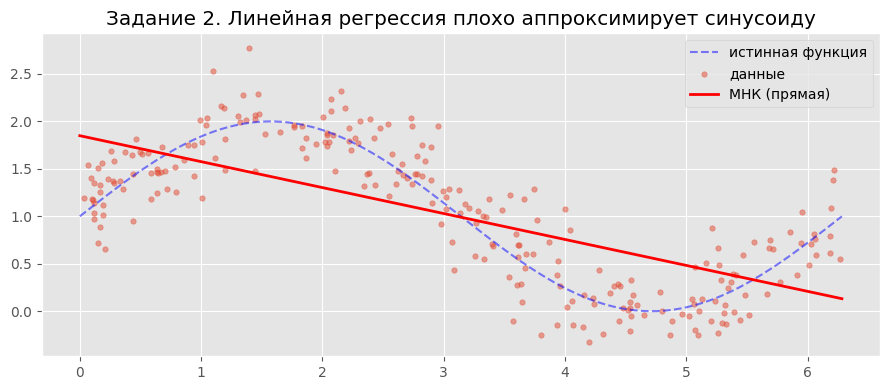

In [ ]:
# Задание 2

def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    data['values']  = np.sin(data['support']) + 1
    data['x_train'] = np.sort(
        np.random.choice(data['support'], size=n_train, replace=True)
    )
    data['y_train'] = (
        np.sin(data['x_train']) + 1
        + np.random.normal(0, std, size=data['x_train'].shape[0])
    )
    return data

data = generate_wave_set(1000, 250)

X_wave       = data['x_train'].reshape(-1, 1)
y_wave       = data['y_train']
X_wave_bias  = np.hstack([X_wave, np.ones((X_wave.shape[0], 1))])

w_wave = np.linalg.inv(X_wave_bias.T @ X_wave_bias) @ X_wave_bias.T @ y_wave
y_pred_wave = X_wave_bias @ w_wave

mse_wave = mean_squared_error(y_wave, y_pred_wave)
mae_wave = mean_absolute_error(y_wave, y_pred_wave)
print(f"\nЗадание 2. МНК на синусоиде: MSE={mse_wave:.4f}, MAE={mae_wave:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='истинная функция')
plt.scatter(data['x_train'], data['y_train'], s=15, alpha=0.5, label='данные')
plt.plot(
    data['support'],
    w_wave[0] * data['support'] + w_wave[1],
    'r', linewidth=2, label='МНК (прямая)'
)
plt.legend()
plt.title('Задание 2. Линейная регрессия плохо аппроксимирует синусоиду')
plt.tight_layout()
plt.show()

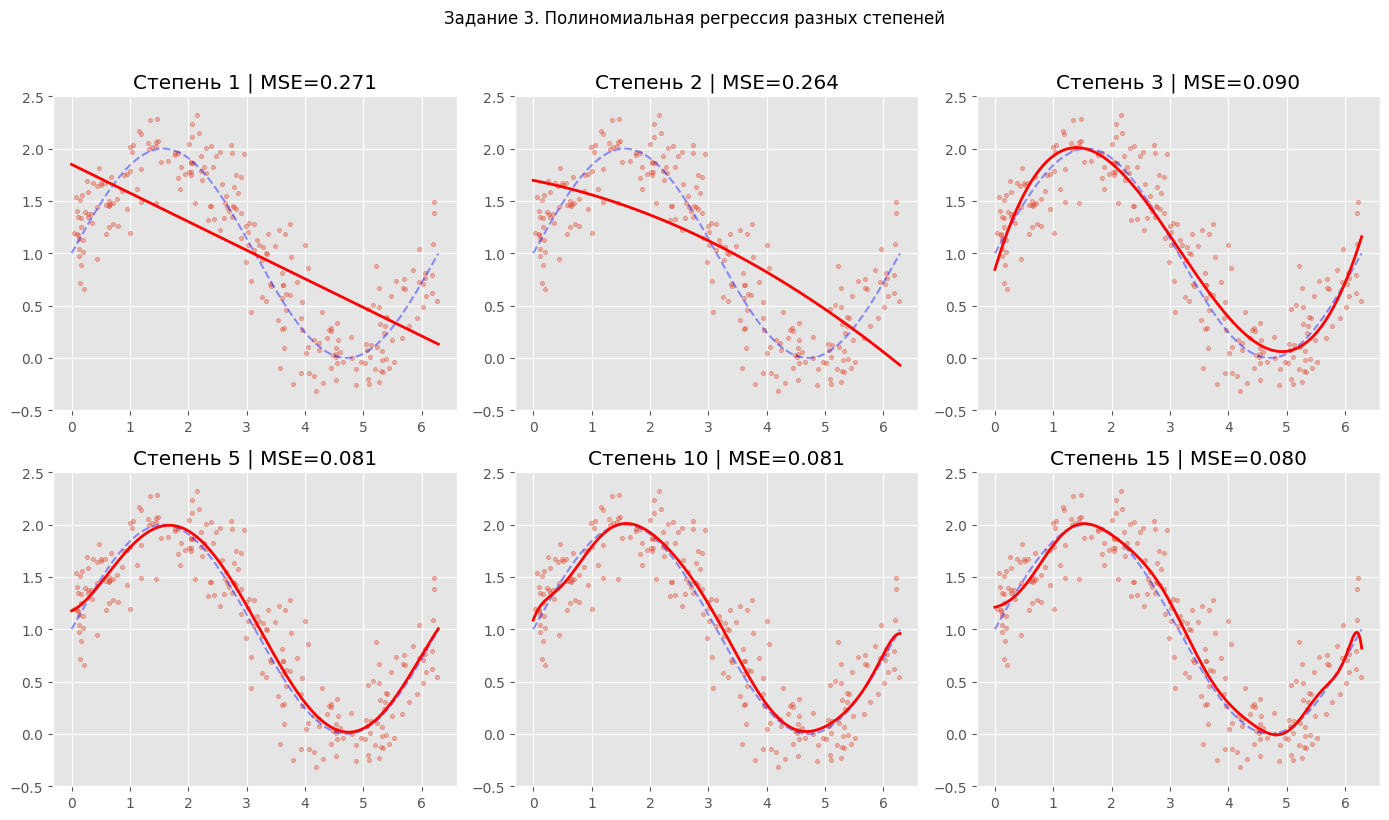

Степень 3–5 оптимальна: хорошо приближает синусоиду без переобучения. Степени 10–15 переобучаются: MSE на обучении низкий, но кривая 'скачет'.


In [ ]:
# Задание 3


degrees = [1, 2, 3, 5, 10, 15]
support = data['support'].reshape(-1, 1)

plt.figure(figsize=(14, 8))
for i, deg in enumerate(degrees, 1):
    poly     = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly   = poly.fit_transform(X_wave)
    model_p  = LinearRegression()
    model_p.fit(X_poly, y_wave)

    X_sup_poly = poly.transform(support)
    y_sup_pred = model_p.predict(X_sup_poly)

    mse_p = mean_squared_error(y_wave, model_p.predict(X_poly))

    plt.subplot(2, 3, i)
    plt.plot(data['support'], data['values'], 'b--', alpha=0.4, label='истина')
    plt.scatter(data['x_train'], data['y_train'], s=10, alpha=0.4)
    plt.plot(data['support'], y_sup_pred, 'r', linewidth=2)
    plt.title(f'Степень {deg} | MSE={mse_p:.3f}')
    plt.ylim(-0.5, 2.5)

plt.suptitle('Задание 3. Полиномиальная регрессия разных степеней', y=1.02)
plt.tight_layout()
plt.show()

print("Степень 3–5 оптимальна: хорошо приближает синусоиду без переобучения. Степени 10–15 переобучаются: MSE на обучении низкий, но кривая 'скачет'.")


Задание 4
Полный датасет (13 признаков) — MSE: 21.8948, MAE: 3.2709
Топ-7 признаков: ['nox', 'rm', 'chas', 'dis', 'ptratio', 'lstat', 'rad']
Усечённый датасет (7 признаков) — MSE: 23.8785, MAE: 3.4716


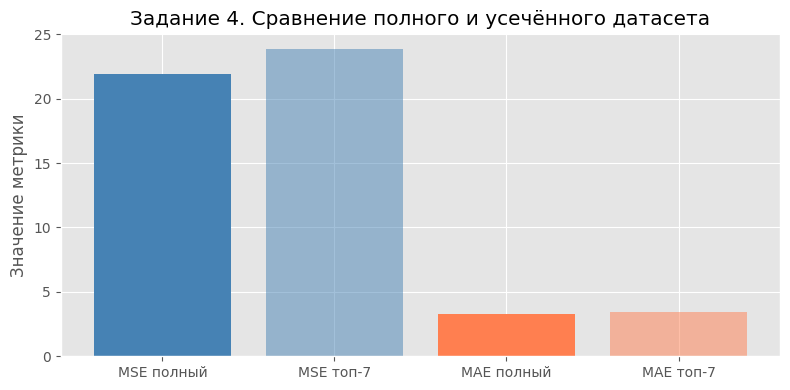

При сокращении до 7 признаков MSE вырос с 21.89 до 23.88,
MAE — с 3.27 до 3.47.
Небольшое ухудшение ожидаемо, но модель стала проще и интерпретируемее.


In [ ]:
# Задание 4

import io, requests

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(url)

X_boston = boston_df.drop('medv', axis=1)
y_boston = boston_df['medv']

feature_names = X_boston.columns.tolist()

# Полный датасет
model_full = LinearRegression()
model_full.fit(X_boston, y_boston)
y_pred_full = model_full.predict(X_boston)

mse_full = mean_squared_error(y_boston, y_pred_full)
mae_full = mean_absolute_error(y_boston, y_pred_full)
print(f"\nЗадание 4")
print(f"Полный датасет ({X_boston.shape[1]} признаков) — MSE: {mse_full:.4f}, MAE: {mae_full:.4f}")

# Определяем 7 наиболее значимых признаков по модулю коэффициента.
# Примечание: признаки не стандартизированы, поэтому коэффициенты зависят от масштаба переменных — метод даёт приближённую оценку важности.
importances = pd.Series(np.abs(model_full.coef_), index=feature_names)
top7 = importances.nlargest(7).index.tolist()
print(f"Топ-7 признаков: {top7}")

# Усечённый датасет
X_boston_top7 = X_boston[top7]
model_top7 = LinearRegression()
model_top7.fit(X_boston_top7, y_boston)
y_pred_top7 = model_top7.predict(X_boston_top7)

mse_top7 = mean_squared_error(y_boston, y_pred_top7)
mae_top7 = mean_absolute_error(y_boston, y_pred_top7)
print(f"Усечённый датасет (7 признаков) — MSE: {mse_top7:.4f}, MAE: {mae_top7:.4f}")

# Сравнительный график
labels  = ['MSE полный', 'MSE топ-7', 'MAE полный', 'MAE топ-7']
values  = [mse_full, mse_top7, mae_full, mae_top7]
colors  = ['steelblue', 'steelblue', 'coral', 'coral']
alphas  = [1.0, 0.5, 1.0, 0.5]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
plt.ylabel('Значение метрики')
plt.title('Задание 4. Сравнение полного и усечённого датасета')
plt.tight_layout()
plt.show()


print(f"При сокращении до 7 признаков MSE вырос с {mse_full:.2f} до {mse_top7:.2f},")
print(f"MAE — с {mae_full:.2f} до {mae_top7:.2f}.")
print("Небольшое ухудшение ожидаемо, но модель стала проще и интерпретируемее.")

In [ ]:
%%capture
!wget -nc https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx
!wget -nc https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

training_data = pd.read_excel('predict_house_price_training_data.xlsx')
test_data     = pd.read_excel('predict_house_price_test_data.xlsx')

target_variable_name = 'Целевая.Цена'
training_values = training_data[target_variable_name]
training_points = training_data.drop(target_variable_name, axis=1)
test_values = test_data[target_variable_name]
test_points = test_data.drop(target_variable_name, axis=1)

linear_regression_model = linear_model.LinearRegression()
linear_regression_model.fit(training_points, training_values)

LinearRegression()

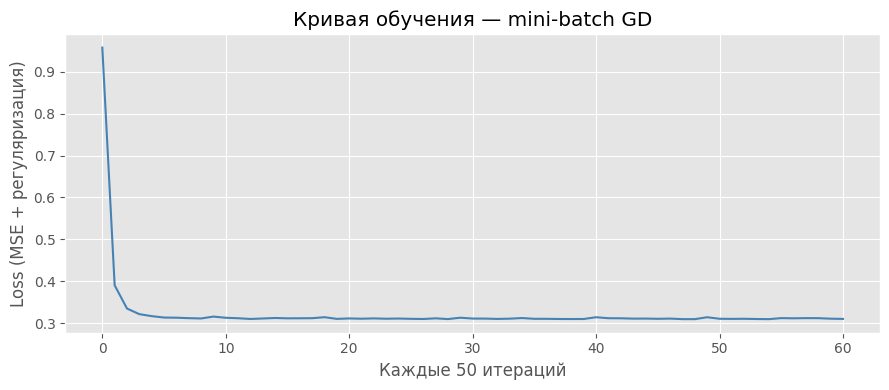

In [ ]:
# Задание 5


class MiniBatchLinearRegression:
    """
    Линейная регрессия на основе mini-batch градиентного спуска.
    Поддерживает регуляризацию Elastic Net (L1 + L2).
    При lambda2=0 соответствует Lasso, при lambda1=0 — Ridge.

    """

    def __init__(
        self,
        learning_rate=0.01,
        n_iterations=1000,
        batch_size=32,
        lambda1=0.0001,   # L1-регуляризация (Lasso)
        lambda2=0.0001,   # L2-регуляризация (Ridge)
        tol=1e-6,
        random_state=42,
    ):
        self.learning_rate = learning_rate
        self.n_iterations  = n_iterations
        self.batch_size    = batch_size
        self.lambda1       = lambda1
        self.lambda2       = lambda2
        self.tol           = tol
        self.random_state  = random_state

        # Параметры модели (заполняются при fit)
        self.w             = None
        self.b             = None
        self.loss_history  = []

        # Параметры масштабирования
        self._scaler_X     = StandardScaler()
        self._scaler_y     = StandardScaler()

    def fit(self, X, y):
        # Приводим к numpy
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).ravel()

        n_objects, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        # Стандартизация X
        X_scaled = self._scaler_X.fit_transform(X)

        # Стандартизация y
        y_2d     = y.reshape(-1, 1)
        y_scaled = self._scaler_y.fit_transform(y_2d).ravel()

        # Инициализация весов нулями
        w = np.zeros(n_features)
        b = 0.0

        self.loss_history = []
        prev_loss = np.inf

        # Цикл обучения
        for iteration in range(self.n_iterations):

            # Случайный mini-batch
            indices = rng.choice(n_objects, size=self.batch_size, replace=False)

            # Данные batch
            X_batch = X_scaled[indices]       # (batch_size, n_features)
            y_batch = y_scaled[indices]       # (batch_size,)

            # Предсказания на batch
            y_hat_batch = X_batch @ w + b

            # Ошибки
            errors = y_hat_batch - y_batch    # (batch_size,)

            m = len(y_batch)

            # Градиент MSE по весам (множитель 2 поглощён learning_rate)
            grad_w = (1 / m) * X_batch.T @ errors

            # Добавляем штраф L2
            grad_w = grad_w + self.lambda2 * w

            # Добавляем штраф L1
            grad_w = grad_w + self.lambda1 * np.sign(w)

            # Градиент по bias
            grad_b = np.mean(errors)

            # Обновление параметров
            w = w - self.learning_rate * grad_w
            b = b - self.learning_rate * grad_b

            # Периодически считаем loss на всей выборке
            if iteration % 50 == 0 or iteration == self.n_iterations - 1:
                y_hat_all = X_scaled @ w + b
                mse  = np.mean((y_hat_all - y_scaled) ** 2)
                reg  = (self.lambda2 / 2) * np.sum(w ** 2) \
                     + self.lambda1 * np.sum(np.abs(w))
                loss = mse + reg
                self.loss_history.append(loss)

                # Ранняя остановка
                if abs(prev_loss - loss) < self.tol:
                    print(f"Ранняя остановка на итерации {iteration}")
                    break
                prev_loss = loss

        self.w = w
        self.b = b
        return self

    def predict(self, X):
        X        = np.array(X, dtype=float)
        X_scaled = self._scaler_X.transform(X)
        y_scaled = X_scaled @ self.w + self.b
        # Обратное масштабирование целевой переменной
        y_pred   = self._scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
        return y_pred

    @property
    def coef_(self):
        """
        Возвращает веса в исходном пространстве признаков (удобно для задания 7).

        """
        return self.w

# Обучаем нашу модель
my_model = MiniBatchLinearRegression(
    learning_rate=0.01,
    n_iterations=3000,
    batch_size=64,
    lambda1=0.0001,   # Elastic Net: оба параметра > 0
    lambda2=0.0001,
    tol=1e-8,
    random_state=42,
)
my_model.fit(training_points, training_values)

# График сходимости
plt.figure(figsize=(9, 4))
plt.plot(my_model.loss_history, color='steelblue')
plt.xlabel('Каждые 50 итераций')
plt.ylabel('Loss (MSE + регуляризация)')
plt.title('Кривая обучения — mini-batch GD')
plt.tight_layout()
plt.show()

Метрика          sklearn LR  Mini-batch GD
MAE               126852.51      126541.96
MSE          40756843765.10 40934087543.37
RMSE              201883.24      202321.74


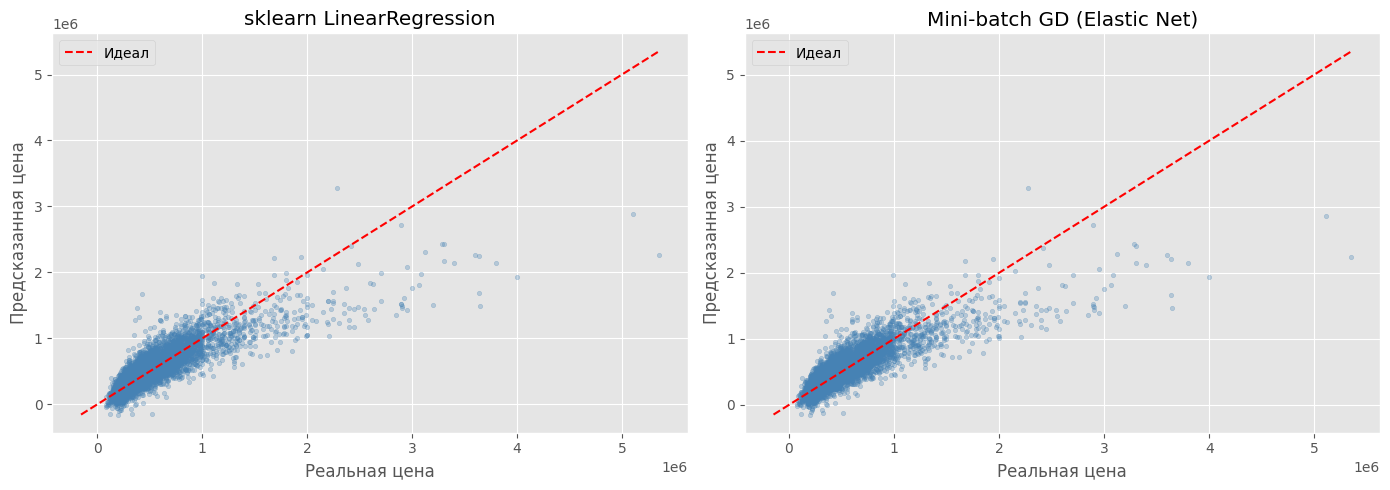

In [ ]:
# Задание 6
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_predictions_linear = linear_regression_model.predict(test_points)
test_predictions_my     = my_model.predict(test_points)

mae_linear = mean_absolute_error(test_values, test_predictions_linear)
mse_linear = mean_squared_error(test_values, test_predictions_linear)

mae_my     = mean_absolute_error(test_values, test_predictions_my)
mse_my     = mean_squared_error(test_values, test_predictions_my)

print("=" * 50)
print(f"{'Метрика':<12} {'sklearn LR':>14} {'Mini-batch GD':>14}")
print("=" * 50)
print(f"{'MAE':<12} {mae_linear:>14.2f} {mae_my:>14.2f}")
print(f"{'MSE':<12} {mse_linear:>14.2f} {mse_my:>14.2f}")
print(f"{'RMSE':<12} {np.sqrt(mse_linear):>14.2f} {np.sqrt(mse_my):>14.2f}")
print("=" * 50)

# Визуальное сравнение предсказаний
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(
    axes,
    [test_predictions_linear, test_predictions_my],
    ['sklearn LinearRegression', 'Mini-batch GD (Elastic Net)'],
):
    ax.scatter(test_values, preds, alpha=0.3, s=10, color='steelblue')
    lim = [min(test_values.min(), preds.min()), max(test_values.max(), preds.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Идеал')
    ax.set_xlabel('Реальная цена')
    ax.set_ylabel('Предсказанная цена')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

  Название признака  Важность признака
        Вид на воду      591890.462867
             Широта      570765.125799
            Долгота      108281.940471
    Оценка риелтора       99635.317145
  Просмотрены ранее       49759.881549
             Ванные       43121.015073
            Спальни       33756.870035
          Состояние       32162.797820
  Количество этажей        6336.716142
      Год постройки        2449.058277
      Жилая площадь         115.347631
Площадь без подвала          79.972561
    Площадь подвала          35.375070
      Год реновации          24.569091
      Общая площадь           0.047273


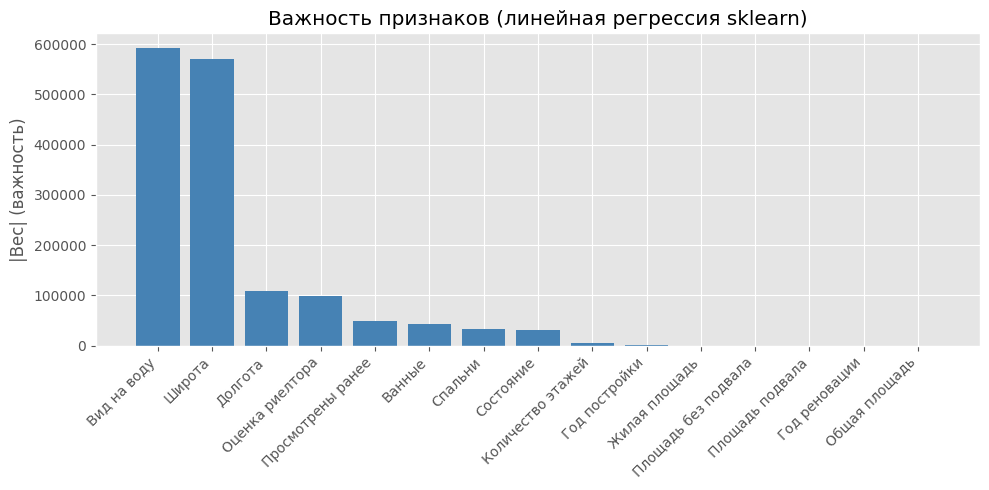

In [ ]:
# Задание 7

from sklearn.preprocessing import StandardScaler

# Стандартизируем признаки перед оценкой важности, чтобы коэффициенты были сопоставимы между собой
scaler_boston = StandardScaler()
X_train_scaled = scaler_boston.fit_transform(training_points)

model_scaled = linear_model.LinearRegression()
model_scaled.fit(X_train_scaled, training_values)

importances = np.abs(model_scaled.coef_)

feature_importance = pd.DataFrame({
    'Название признака': training_points.columns,
    'Важность признака': importances,
})

feature_importance = feature_importance.sort_values(
    by='Важность признака', ascending=False
).reset_index(drop=True)

print(feature_importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(
    feature_importance['Название признака'],
    feature_importance['Важность признака'],
    color='steelblue',
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('|Вес| (важность, стандартизированные признаки)')
plt.title('Важность признаков (коэффициенты на стандартизированных данных)')
plt.tight_layout()
plt.show()



Найдено аномально дешёвых объектов: 67
      Целевая.Цена  Предсказанная цена       Остаток
632         425000        1.675003e+06  1.250003e+06
4675        380000        1.459378e+06  1.079378e+06
1032       2280000        3.282973e+06  1.002973e+06
4270        995000        1.949650e+06  9.546501e+05
3502        400000        1.328605e+06  9.286053e+05
2765        357000        1.278702e+06  9.217022e+05
2426        600000        1.391778e+06  7.917783e+05
4838       1110000        1.844002e+06  7.340025e+05
842         345600        1.046715e+06  7.011154e+05
4643        650000        1.333893e+06  6.838929e+05
3511        600000        1.282137e+06  6.821368e+05
4354        600000        1.273379e+06  6.733794e+05
2739        603500        1.262452e+06  6.589517e+05
6303        452000        1.110602e+06  6.586020e+05
277         500000        1.154628e+06  6.546283e+05
4438        650000        1.303564e+06  6.535640e+05
1834        540000        1.168328e+06  6.283282e+05
6088  

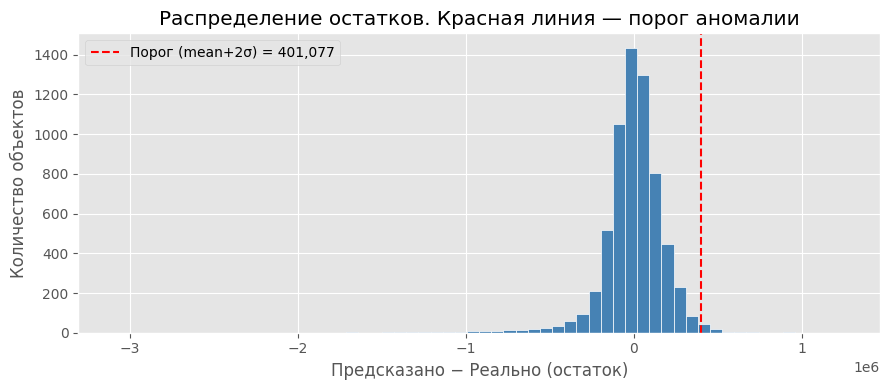

In [ ]:
# Задание 8
# Предсказываем цену по всей тестовой выборке
predicted_prices  = linear_regression_model.predict(test_points)
actual_prices     = test_values.values
residuals = predicted_prices - actual_prices

# residuals = predicted - actual: residuals > 0 означает: модель предсказала больше реальной цены,
# то есть объект стоит ДЕШЕВЛЕ чем ожидает модель — это и есть "аномально дешёвые".
# Порог: отклонение больше mean + 2σ
threshold = residuals.mean() + 2 * residuals.std()
anomaly_mask = residuals > threshold

anomaly_df = test_data.copy()
anomaly_df['Предсказанная цена'] = predicted_prices
anomaly_df['Остаток']            = residuals
anomaly_df = anomaly_df[anomaly_mask].sort_values('Остаток', ascending=False)

print(f"\nНайдено аномально дешёвых объектов: {len(anomaly_df)}")
print(anomaly_df[['Целевая.Цена', 'Предсказанная цена', 'Остаток']].to_string())

# Гистограмма остатков
plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(threshold, color='red', linestyle='--', label=f'Порог (mean+2σ) = {threshold:,.0f}')
plt.xlabel('Предсказано − Реально (остаток)')
plt.ylabel('Количество объектов')
plt.title('Распределение остатков. Красная линия — порог аномалии')
plt.legend()
plt.tight_layout()
plt.show()